In [16]:
import os, json, random, cv2, torch
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as T
from torchvision.models.swin_transformer import swin_t, Swin_T_Weights
from torchvision.models.resnet import resnet50, ResNet50_Weights
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from PIL import Image
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURATION (Edit here)
# ==========================================
RUN_MODE = "train"  # Change to "validate" after training
MODEL_SAVE_PATH = "sciguard_best_model.pt"
IMG_SIZE = 512
BATCH_SIZE = 8      # Increased for speed
EPOCHS = 10         # Goal for your review

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paths
BASE_DIR = "/kaggle/input/datasets/ananyalakshmi09/sifd-dataset/sifd/recodai-luc-scientific-image-forgery-detection"
AUTH_DIR, FORG_DIR = f"{BASE_DIR}/train_images/authentic", f"{BASE_DIR}/train_images/forged"
MASK_DIR = f"{BASE_DIR}/train_masks"

# ==========================================
# 2. ARCHITECTURE & DATASET
# ==========================================
class SRMConv2d(nn.Module):
    def __init__(self, inc=3):
        super().__init__()
        q = [4.0, 12.0, 2.0]
        f1 = [[0,0,0,0,0],[0,-1,2,-1,0],[0,2,-4,2,0],[0,-1,2,-1,0],[0,0,0,0,0]]
        f2 = [[-1,2,-2,2,-1],[2,-6,8,-6,2],[-2,8,-12,8,-2],[2,-6,8,-6,2],[-1,2,-2,2,-1]]
        f3 = [[0,0,0,0,0],[0,0,0,0,0],[0,1,-2,1,0],[0,0,0,0,0],[0,0,0,0,0]]
        filters = torch.FloatTensor(np.stack([np.array(f1)/q[0], np.array(f2)/q[1], np.array(f3)/q[2]], 0)).unsqueeze(1).repeat(1, inc, 1, 1)
        self.conv = nn.Conv2d(inc, 3, 5, 1, 2, bias=False)
        self.conv.weight = nn.Parameter(filters, requires_grad=False)
    def forward(self, x): return torch.clamp(self.conv(x), -2, 2)

class SciGuard(nn.Module):
    def __init__(self):
        super().__init__()
        self.rgb_stream = nn.Sequential(*list(resnet50(weights=ResNet50_Weights.IMAGENET1K_V2).children())[:-2])
        self.noise_stream = swin_t(weights=Swin_T_Weights.IMAGENET1K_V1).features
        self.rgb_proj = nn.Conv2d(2048, 768, 1)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(768, 256, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(256, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 1, 4, 2, 1)
        )
    def forward(self, rgb, noise):
        feat = self.rgb_proj(self.rgb_stream(rgb))
        n_feat = self.noise_stream(noise).permute(0,3,1,2).contiguous()
        if feat.shape[2:] != n_feat.shape[2:]:
            n_feat = F.interpolate(n_feat, size=feat.shape[2:], mode='bilinear')
        return F.interpolate(self.decoder(feat + n_feat), size=(IMG_SIZE, IMG_SIZE), mode='bilinear')

class SciDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths
        self.srm = SRMConv2d()
        self.tf = T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor()])
        self.norm = T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        p = self.paths[idx]
        img = Image.open(p).convert("RGB")
        orig_t = self.tf(img)
        rgb = self.norm(orig_t)
        with torch.no_grad(): noise = self.srm(orig_t.unsqueeze(0)).squeeze(0)
        mask_path = os.path.join(MASK_DIR, Path(p).stem + ".npy")
        if "forged" in p and os.path.exists(mask_path):
            m = np.load(mask_path)
            if m.ndim == 3: m = np.max(m, axis=0)
            m = cv2.resize((m > 0).astype(np.float32), (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
            return rgb, noise, torch.tensor(m).unsqueeze(0)
        return rgb, noise, torch.zeros((1, IMG_SIZE, IMG_SIZE))

# ==========================================
# 3. NITRO CORE LOGIC (AMP + OPTIMIZED LOADERS)
# ==========================================
def run_train():
    auth = [str(Path(AUTH_DIR)/f) for f in os.listdir(AUTH_DIR) if f.endswith(('.png', '.jpg'))]
    forg = [str(Path(FORG_DIR)/f) for f in os.listdir(FORG_DIR) if f.endswith(('.png', '.jpg'))]
    tr_p, _ = train_test_split(auth + forg, test_size=0.2, random_state=42)
    
    loader = DataLoader(SciDataset(tr_p), batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
    model = SciGuard().to(device)
    opt = optim.AdamW(model.parameters(), lr=1e-4)
    crit = nn.BCEWithLogitsLoss()
    scaler = GradScaler()

    print(f"Starting Nitro Training for {EPOCHS} Epochs...")
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
        for rgb, noise, mask in pbar:
            rgb, noise, mask = rgb.to(device), noise.to(device), mask.to(device)
            opt.zero_grad()
            with autocast():
                loss = crit(model(rgb, noise), mask)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            epoch_loss += loss.item()
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})
        
        print(f"Epoch {epoch+1} Avg Loss: {epoch_loss/len(loader):.4f}")
        torch.save(model.state_dict(), MODEL_SAVE_PATH)

def run_validate():
    model = SciGuard().to(device)
    if not os.path.exists(MODEL_SAVE_PATH):
        print("No model file found. Train first!")
        return
    model.load_state_dict(torch.load(MODEL_SAVE_PATH))
    model.eval()

    auth = [str(Path(AUTH_DIR)/f) for f in os.listdir(AUTH_DIR) if f.endswith(('.png', '.jpg'))]
    forg = [str(Path(FORG_DIR)/f) for f in os.listdir(FORG_DIR) if f.endswith(('.png', '.jpg'))]
    _, vl_p = train_test_split(auth + forg, test_size=0.2, random_state=42)
    
    loader = DataLoader(SciDataset(vl_p), batch_size=1, num_workers=2)
    all_preds, all_masks = [], []

    print("Generating Presentation Visuals & F1 Score...")
    for i, (rgb, noise, mask) in enumerate(tqdm(loader)):
        if i > 150: break # Sample for speed
        rgb, noise = rgb.to(device), noise.to(device)
        with torch.no_grad():
            with autocast():
                pred_logits = model(rgb, noise)
            pred_probs = torch.sigmoid(pred_logits).cpu().numpy()[0,0]
            pred_binary = (pred_probs > 0.5).astype(np.uint8)
        
        all_preds.append(pred_binary.flatten())
        all_masks.append(mask.numpy().flatten())

        # Show top 3 forged samples for slides
        if i < 5 and mask.max() > 0:
            fig, ax = plt.subplots(1, 3, figsize=(15, 5))
            disp_img = rgb.cpu().squeeze(0).permute(1,2,0).numpy()
            disp_img = np.clip((disp_img * 0.229) + 0.485, 0, 1)
            ax[0].imshow(disp_img); ax[0].set_title("Input Image")
            ax[0].axis('off')
            ax[1].imshow(pred_probs, cmap='jet'); ax[1].set_title("AI Heatmap (Detection)")
            ax[1].axis('off')
            ax[2].imshow(mask.squeeze(), cmap='gray'); ax[2].set_title("Ground Truth (Answer)")
            ax[2].axis('off')
            plt.show()

    f1 = f1_score(np.concatenate(all_masks), np.concatenate(all_preds), zero_division=1)
    print(f"\n🏆 VALIDATION F1 SCORE: {f1:.4f}")

# ==========================================
# 4. EXECUTION
# ==========================================
if __name__ == "__main__":
    if RUN_MODE == "train":
        run_train()
    elif RUN_MODE == "validate":
        run_validate()

/tmp/ipykernel_55/2811268432.py:265: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Starting Nitro Training for 10 Epochs...


Epoch 1/10:   0%|          | 0/513 [00:00<?, ?it/s]/tmp/ipykernel_55/2811268432.py:275: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/10: 100%|██████████| 513/513 [04:08<00:00,  2.06it/s, loss=0.0463]


Epoch 1 Avg Loss: 0.1064


Epoch 2/10: 100%|██████████| 513/513 [04:07<00:00,  2.07it/s, loss=0.0855]


...

Epoch 8 Avg Loss: 0.0470


Epoch 9/10: 100%|██████████| 513/513 [04:07<00:00,  2.07it/s, loss=0.0520]


Epoch 9 Avg Loss: 0.0433


Epoch 10/10: 100%|██████████| 513/513 [04:09<00:00,  2.06it/s, loss=0.0363]


Epoch 10 Avg Loss: 0.0397


In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score

def generate_paper_metrics():
    model = SciGuard().to(device)
    model.load_state_dict(torch.load(MODEL_SAVE_PATH))
    model.eval()

    # Use the validation set (20% unseen data)
    auth = [str(Path(AUTH_DIR)/f) for f in os.listdir(AUTH_DIR) if f.endswith(('.png', '.jpg'))]
    forg = [str(Path(FORG_DIR)/f) for f in os.listdir(FORG_DIR) if f.endswith(('.png', '.jpg'))]
    _, vl_p = train_test_split(auth + forg, test_size=0.2, random_state=42)
    loader = DataLoader(SciDataset(vl_p), batch_size=1)

    y_true, y_pred = [], []
    print("Gathering Quantitative Data for the Research Paper...")

    with torch.no_grad():
        for rgb, noise, mask in tqdm(loader):
            outputs = torch.sigmoid(model(rgb.to(device), noise.to(device))).cpu().numpy()[0,0]
            y_pred.append((outputs > 0.5).astype(np.uint8).flatten())
            y_true.append(mask.numpy().astype(np.uint8).flatten())

    y_true, y_pred = np.concatenate(y_true), np.concatenate(y_pred)
    
    # These are your "Table 1" values
    results = {
        "Precision": precision_score(y_true, y_pred, zero_division=1),
        "Recall": recall_score(y_true, y_pred, zero_division=1),
        "F1-Score": f1_score(y_true, y_pred, zero_division=1)
    }
    
    print("\n--- TABLE: MODEL PERFORMANCE METRICS ---")
    for k, v in results.items(): print(f"{k}: {v:.4f}")
    return results

generate_paper_metrics()

Gathering Quantitative Data for the Research Paper...


100%|██████████| 1026/1026 [01:42<00:00, 10.04it/s]



--- TABLE: MODEL PERFORMANCE METRICS ---
Precision: 0.5136
Recall: 0.4597
F1-Score: 0.4852


{'Precision': 0.5136355851665788,
 'Recall': 0.4597117772201915,
 'F1-Score': 0.4851799816284587}

Generating Presentation Visuals & F1 Score...


  0%|          | 0/1026 [00:00<?, ?it/s]/tmp/ipykernel_55/3443358360.py:142: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


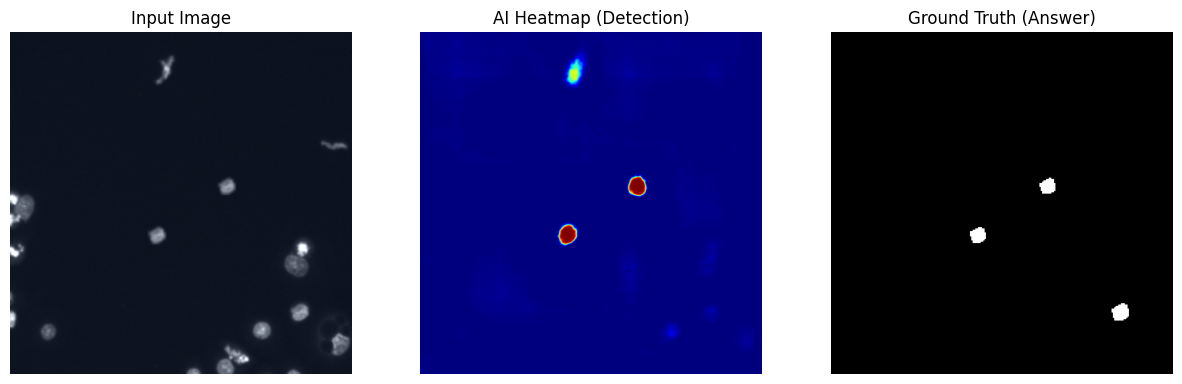

  0%|          | 1/1026 [00:00<13:10,  1.30it/s]

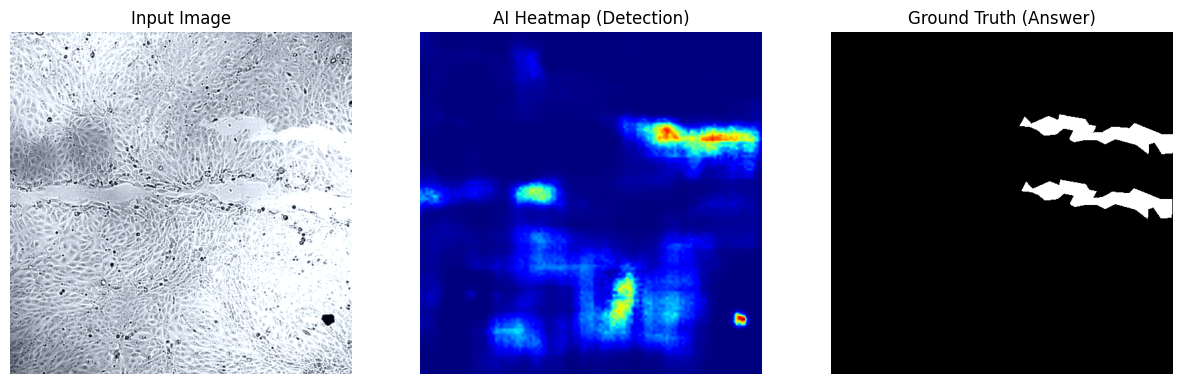

  0%|          | 2/1026 [00:01<09:34,  1.78it/s]

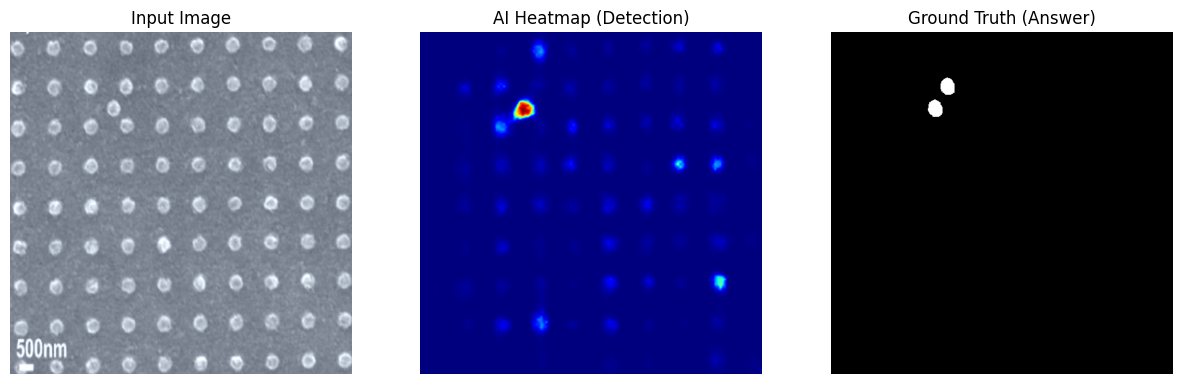

  0%|          | 3/1026 [00:01<08:06,  2.10it/s]

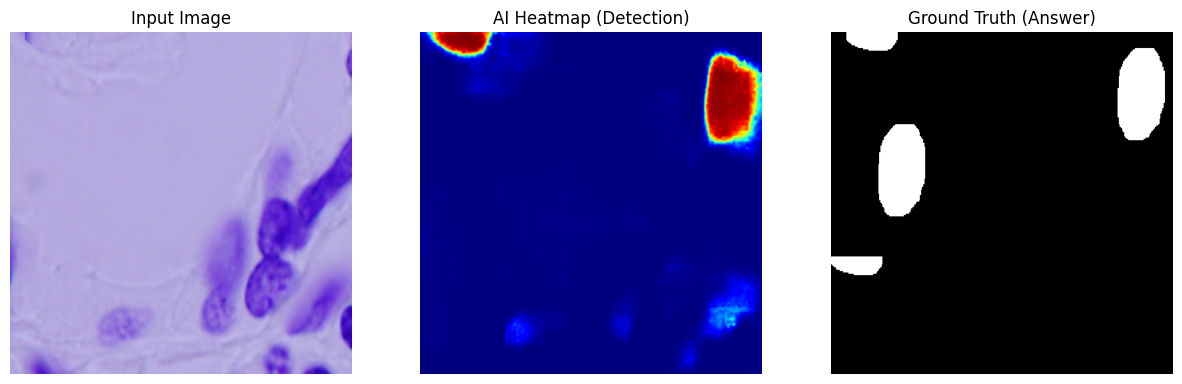

 15%|█▍        | 151/1026 [00:11<01:06, 13.12it/s]



🏆 VALIDATION F1 SCORE: 0.4446


In [18]:
import os, json, random, cv2, torch
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as T
from torchvision.models.swin_transformer import swin_t, Swin_T_Weights
from torchvision.models.resnet import resnet50, ResNet50_Weights
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from PIL import Image
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURATION (Edit here)
# ==========================================
RUN_MODE = "validate"  # Change to "validate" after training
MODEL_SAVE_PATH = "sciguard_best_model.pt"
IMG_SIZE = 512
BATCH_SIZE = 8      # Increased for speed
EPOCHS = 10         # Goal for your review

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paths
BASE_DIR = "/kaggle/input/datasets/ananyalakshmi09/sifd-dataset/sifd/recodai-luc-scientific-image-forgery-detection"
AUTH_DIR, FORG_DIR = f"{BASE_DIR}/train_images/authentic", f"{BASE_DIR}/train_images/forged"
MASK_DIR = f"{BASE_DIR}/train_masks"

# ==========================================
# 2. ARCHITECTURE & DATASET
# ==========================================
class SRMConv2d(nn.Module):
    def __init__(self, inc=3):
        super().__init__()
        q = [4.0, 12.0, 2.0]
        f1 = [[0,0,0,0,0],[0,-1,2,-1,0],[0,2,-4,2,0],[0,-1,2,-1,0],[0,0,0,0,0]]
        f2 = [[-1,2,-2,2,-1],[2,-6,8,-6,2],[-2,8,-12,8,-2],[2,-6,8,-6,2],[-1,2,-2,2,-1]]
        f3 = [[0,0,0,0,0],[0,0,0,0,0],[0,1,-2,1,0],[0,0,0,0,0],[0,0,0,0,0]]
        filters = torch.FloatTensor(np.stack([np.array(f1)/q[0], np.array(f2)/q[1], np.array(f3)/q[2]], 0)).unsqueeze(1).repeat(1, inc, 1, 1)
        self.conv = nn.Conv2d(inc, 3, 5, 1, 2, bias=False)
        self.conv.weight = nn.Parameter(filters, requires_grad=False)
    def forward(self, x): return torch.clamp(self.conv(x), -2, 2)

class SciGuard(nn.Module):
    def __init__(self):
        super().__init__()
        self.rgb_stream = nn.Sequential(*list(resnet50(weights=ResNet50_Weights.IMAGENET1K_V2).children())[:-2])
        self.noise_stream = swin_t(weights=Swin_T_Weights.IMAGENET1K_V1).features
        self.rgb_proj = nn.Conv2d(2048, 768, 1)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(768, 256, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(256, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 1, 4, 2, 1)
        )
    def forward(self, rgb, noise):
        feat = self.rgb_proj(self.rgb_stream(rgb))
        n_feat = self.noise_stream(noise).permute(0,3,1,2).contiguous()
        if feat.shape[2:] != n_feat.shape[2:]:
            n_feat = F.interpolate(n_feat, size=feat.shape[2:], mode='bilinear')
        return F.interpolate(self.decoder(feat + n_feat), size=(IMG_SIZE, IMG_SIZE), mode='bilinear')

class SciDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths
        self.srm = SRMConv2d()
        self.tf = T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor()])
        self.norm = T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        p = self.paths[idx]
        img = Image.open(p).convert("RGB")
        orig_t = self.tf(img)
        rgb = self.norm(orig_t)
        with torch.no_grad(): noise = self.srm(orig_t.unsqueeze(0)).squeeze(0)
        mask_path = os.path.join(MASK_DIR, Path(p).stem + ".npy")
        if "forged" in p and os.path.exists(mask_path):
            m = np.load(mask_path)
            if m.ndim == 3: m = np.max(m, axis=0)
            m = cv2.resize((m > 0).astype(np.float32), (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
            return rgb, noise, torch.tensor(m).unsqueeze(0)
        return rgb, noise, torch.zeros((1, IMG_SIZE, IMG_SIZE))

# ==========================================
# 3. NITRO CORE LOGIC (AMP + OPTIMIZED LOADERS)
# ==========================================
def run_train():
    auth = [str(Path(AUTH_DIR)/f) for f in os.listdir(AUTH_DIR) if f.endswith(('.png', '.jpg'))]
    forg = [str(Path(FORG_DIR)/f) for f in os.listdir(FORG_DIR) if f.endswith(('.png', '.jpg'))]
    tr_p, _ = train_test_split(auth + forg, test_size=0.2, random_state=42)
    
    loader = DataLoader(SciDataset(tr_p), batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
    model = SciGuard().to(device)
    opt = optim.AdamW(model.parameters(), lr=1e-4)
    crit = nn.BCEWithLogitsLoss()
    scaler = GradScaler()

    print(f"Starting Nitro Training for {EPOCHS} Epochs...")
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
        for rgb, noise, mask in pbar:
            rgb, noise, mask = rgb.to(device), noise.to(device), mask.to(device)
            opt.zero_grad()
            with autocast():
                loss = crit(model(rgb, noise), mask)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            epoch_loss += loss.item()
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})
        
        print(f"Epoch {epoch+1} Avg Loss: {epoch_loss/len(loader):.4f}")
        torch.save(model.state_dict(), MODEL_SAVE_PATH)

def run_validate():
    model = SciGuard().to(device)
    if not os.path.exists(MODEL_SAVE_PATH):
        print("No model file found. Train first!")
        return
    model.load_state_dict(torch.load(MODEL_SAVE_PATH))
    model.eval()

    auth = [str(Path(AUTH_DIR)/f) for f in os.listdir(AUTH_DIR) if f.endswith(('.png', '.jpg'))]
    forg = [str(Path(FORG_DIR)/f) for f in os.listdir(FORG_DIR) if f.endswith(('.png', '.jpg'))]
    _, vl_p = train_test_split(auth + forg, test_size=0.2, random_state=42)
    
    loader = DataLoader(SciDataset(vl_p), batch_size=1, num_workers=2)
    all_preds, all_masks = [], []

    print("Generating Presentation Visuals & F1 Score...")
    for i, (rgb, noise, mask) in enumerate(tqdm(loader)):
        if i > 150: break # Sample for speed
        rgb, noise = rgb.to(device), noise.to(device)
        with torch.no_grad():
            with autocast():
                pred_logits = model(rgb, noise)
            pred_probs = torch.sigmoid(pred_logits).cpu().numpy()[0,0]
            pred_binary = (pred_probs > 0.5).astype(np.uint8)
        
        all_preds.append(pred_binary.flatten())
        all_masks.append(mask.numpy().flatten())

        # Show top 3 forged samples for slides
        if i < 5 and mask.max() > 0:
            fig, ax = plt.subplots(1, 3, figsize=(15, 5))
            disp_img = rgb.cpu().squeeze(0).permute(1,2,0).numpy()
            disp_img = np.clip((disp_img * 0.229) + 0.485, 0, 1)
            ax[0].imshow(disp_img); ax[0].set_title("Input Image")
            ax[0].axis('off')
            ax[1].imshow(pred_probs, cmap='jet'); ax[1].set_title("AI Heatmap (Detection)")
            ax[1].axis('off')
            ax[2].imshow(mask.squeeze(), cmap='gray'); ax[2].set_title("Ground Truth (Answer)")
            ax[2].axis('off')
            plt.show()

    f1 = f1_score(np.concatenate(all_masks), np.concatenate(all_preds), zero_division=1)
    print(f"\n🏆 VALIDATION F1 SCORE: {f1:.4f}")

# ==========================================
# 4. EXECUTION
# ==========================================
if __name__ == "__main__":
    if RUN_MODE == "train":
        run_train()
    elif RUN_MODE == "validate":
        run_validate()

In [20]:
import os, cv2, torch
import numpy as np
import torchvision.transforms as T
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

# ==========================================
# SET YOUR PATHS HERE
# ==========================================
INPUT_FOLDER = "/kaggle/input/datasets/ananyalakshmi09/sifd-dataset/sifd/recodai-luc-scientific-image-forgery-detection/test_images" # Folder with your own images
OUTPUT_FOLDER = "predictions_output"             # Where PNG masks will be saved
MODEL_PATH = "sciguard_best_model.pt"

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

def run_custom_inference():
    # 1. Load Model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = SciGuard().to(device)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()

    # 2. Setup Preprocessing
    srm_filter = SRMConv2d().to(device)
    tf = T.Compose([T.Resize((512, 512)), T.ToTensor()])
    norm = T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

    # 3. Process Folder
    image_files = [f for f in os.listdir(INPUT_FOLDER) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif'))]
    print(f"Found {len(image_files)} images. Starting inference...")

    for filename in image_files:
        img_path = os.path.join(INPUT_FOLDER, filename)
        pil_img = Image.open(img_path).convert("RGB")
        orig_w, orig_h = pil_img.size
        
        # Prepare Tensors
        img_t = tf(pil_img).to(device)
        rgb = norm(img_t).unsqueeze(0)
        with torch.no_grad():
            noise = srm_filter(img_t.unsqueeze(0))
            
            # Predict
            logits = model(rgb, noise)
            probs = torch.sigmoid(logits)[0, 0].cpu().numpy()

        # 4. Save Heatmap (For Paper Figures)
        # Resize back to original size for high-quality output
        probs_resized = cv2.resize(probs, (orig_w, orig_h))
        heatmap_colored = cv2.applyColorMap((probs_resized * 255).astype(np.uint8), cv2.COLORMAP_JET)
        
        # 5. Save Binary Mask (For Quantifiable Proof)
        binary_mask = (probs_resized > 0.5).astype(np.uint8) * 255
        
        # Save files
        cv2.imwrite(f"{OUTPUT_FOLDER}/heatmap_{filename}", heatmap_colored)
        cv2.imwrite(f"{OUTPUT_FOLDER}/mask_{filename}.png", binary_mask)
        
        print(f"Processed: {filename}")

    print(f"\n✅ All masks saved to: {OUTPUT_FOLDER}")

run_custom_inference()

Found 1 images. Starting inference...
Processed: 45.png

✅ All masks saved to: predictions_output
